## **Importing of required Libraries**

In [1]:
# Import required libraries
import os
import shutil
import numpy as np
import pandas as pd

OUTPUT_DIR = "python_models"

# Remove previously generated models
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Clean output directory created: {OUTPUT_DIR}")
import os, math, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, matthews_corrcoef, roc_auc_score, accuracy_score
warnings.filterwarnings('ignore')


Clean output directory created: python_models


## **1. Reading and Understanding of the Training Data**

In [2]:
# Importing dataset
income_df = pd.read_csv('adult.csv')

In [3]:
# Preview dataset
income_df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
# Shape of dataset
income_df.shape

(32561, 15)

In [5]:
# Features data-type
income_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [6]:
# Statistical summary
income_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


## **2. Visualisation of Data and Data Preprocessing:**

In [7]:
# Check for null values
income_df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [8]:
income_df['age'] = pd.to_numeric(income_df['age'], errors='coerce')
income_df['hours.per.week'] = pd.to_numeric(income_df['hours.per.week'], errors='coerce')


In [9]:
# Keep rows; missing values are handled using training-set statistics.
my_df = income_df.copy()


In [10]:
my_df['predclass'] = my_df['income'].astype(str).str.strip()
del my_df['income']


In [11]:
my_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  predclass       32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [12]:
my_df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
predclass         0
dtype: int64

In [13]:
print('workclass',my_df.workclass.unique())
print('education',my_df.education.unique())
print('marital.status',my_df['marital.status'].unique())
print('occupation',my_df.occupation.unique())
print('relationship',my_df.relationship.unique())
print('race',my_df.race.unique())
print('sex',my_df.sex.unique())
print('native.country',my_df['native.country'].unique())
print('predclass',my_df.predclass.unique())

workclass ['?' 'Private' 'State-gov' 'Federal-gov' 'Self-emp-not-inc' 'Self-emp-inc'
 'Local-gov' 'Without-pay' 'Never-worked']
education ['HS-grad' 'Some-college' '7th-8th' '10th' 'Doctorate' 'Prof-school'
 'Bachelors' 'Masters' '11th' 'Assoc-acdm' 'Assoc-voc' '1st-4th' '5th-6th'
 '12th' '9th' 'Preschool']
marital.status ['Widowed' 'Divorced' 'Separated' 'Never-married' 'Married-civ-spouse'
 'Married-spouse-absent' 'Married-AF-spouse']
occupation ['?' 'Exec-managerial' 'Machine-op-inspct' 'Prof-specialty'
 'Other-service' 'Adm-clerical' 'Craft-repair' 'Transport-moving'
 'Handlers-cleaners' 'Sales' 'Farming-fishing' 'Tech-support'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']
relationship ['Not-in-family' 'Unmarried' 'Own-child' 'Other-relative' 'Husband' 'Wife']
race ['White' 'Black' 'Asian-Pac-Islander' 'Other' 'Amer-Indian-Eskimo']
sex ['Female' 'Male']
native.country ['United-States' '?' 'Mexico' 'Greece' 'Vietnam' 'China' 'Taiwan' 'India'
 'Philippines' 'Trinadad&Tobago' '

<Axes: xlabel='count', ylabel='predclass'>

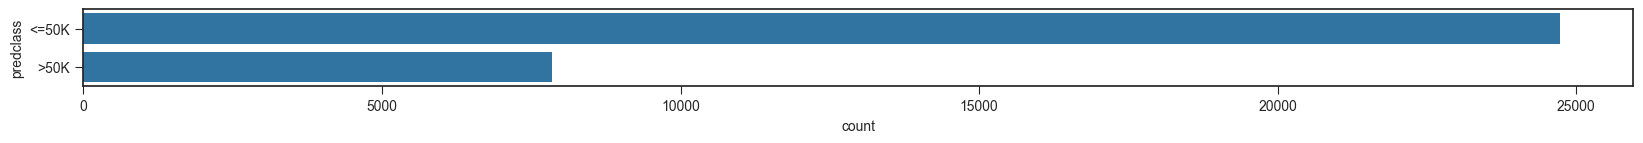

In [14]:
fig = plt.figure(figsize=(20,1))
plt.style.use('seaborn-v0_8-ticks')
sns.countplot(y="predclass", data=my_df)

In [15]:
my_df['education'].replace('Preschool', 'dropout',inplace=True)
my_df['education'].replace('10th', 'dropout',inplace=True)
my_df['education'].replace('11th', 'dropout',inplace=True)
my_df['education'].replace('12th', 'dropout',inplace=True)
my_df['education'].replace('1st-4th', 'dropout',inplace=True)
my_df['education'].replace('5th-6th', 'dropout',inplace=True)
my_df['education'].replace('7th-8th', 'dropout',inplace=True)
my_df['education'].replace('9th', 'dropout',inplace=True)
my_df['education'].replace('HS-Grad', 'HighGrad',inplace=True)
my_df['education'].replace('HS-grad', 'HighGrad',inplace=True)
my_df['education'].replace('Some-college', 'CommunityCollege',inplace=True)
my_df['education'].replace('Assoc-acdm', 'CommunityCollege',inplace=True)
my_df['education'].replace('Assoc-voc', 'CommunityCollege',inplace=True)
my_df['education'].replace('Bachelors', 'Bachelors',inplace=True)
my_df['education'].replace('Masters', 'Masters',inplace=True)
my_df['education'].replace('Prof-school', 'Masters',inplace=True)
my_df['education'].replace('Doctorate', 'Doctorate',inplace=True)

In [16]:
my_df[['education', 'education.num']].groupby(['education'], as_index=False).mean().sort_values(by='education.num', ascending=False)

,education,education.num
2,Doctorate,16.000000
4,Masters,14.250544
0,Bachelors,13.000000
1,CommunityCollege,10.360986
3,HighGrad,9.000000
5,dropout,5.602398


<Axes: xlabel='count', ylabel='education'>

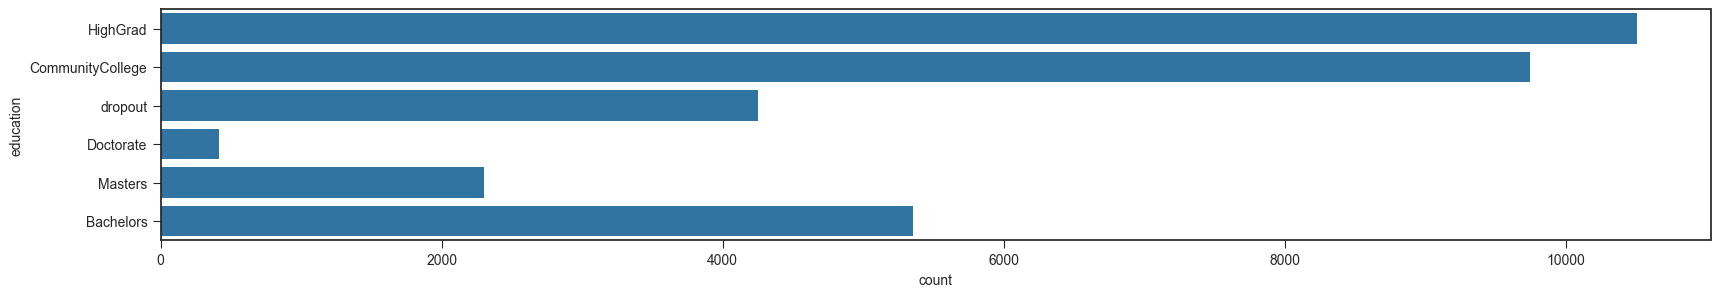

In [17]:
fig = plt.figure(figsize=(20,3))
plt.style.use('seaborn-v0_8-ticks')
sns.countplot(y="education", data=my_df)

In [18]:
my_df['marital.status'].replace('Never-married', 'NotMarried',inplace=True)
my_df['marital.status'].replace(['Married-AF-spouse'], 'Married',inplace=True)
my_df['marital.status'].replace(['Married-civ-spouse'], 'Married',inplace=True)
my_df['marital.status'].replace(['Married-spouse-absent'], 'NotMarried',inplace=True)
my_df['marital.status'].replace(['Separated'], 'Separated',inplace=True)
my_df['marital.status'].replace(['Divorced'], 'Separated',inplace=True)
my_df['marital.status'].replace(['Widowed'], 'Widowed',inplace=True)

<Axes: xlabel='count', ylabel='marital.status'>

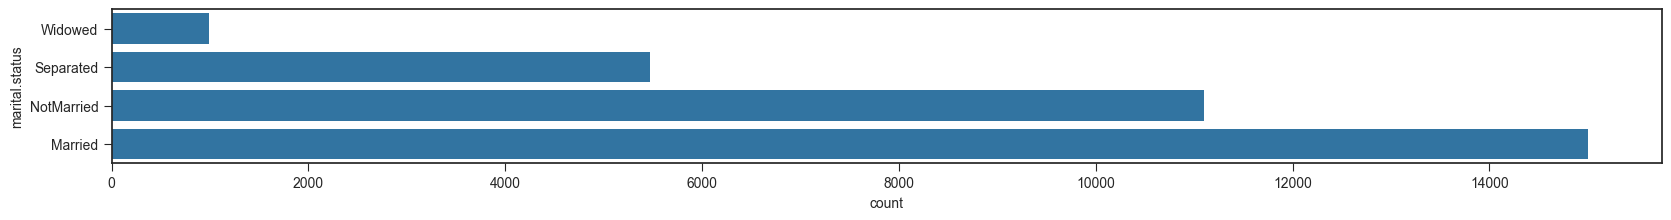

In [19]:
fig = plt.figure(figsize=(20,2))
plt.style.use('seaborn-v0_8-ticks')
sns.countplot(y="marital.status", data=my_df)

<Axes: xlabel='count', ylabel='occupation'>

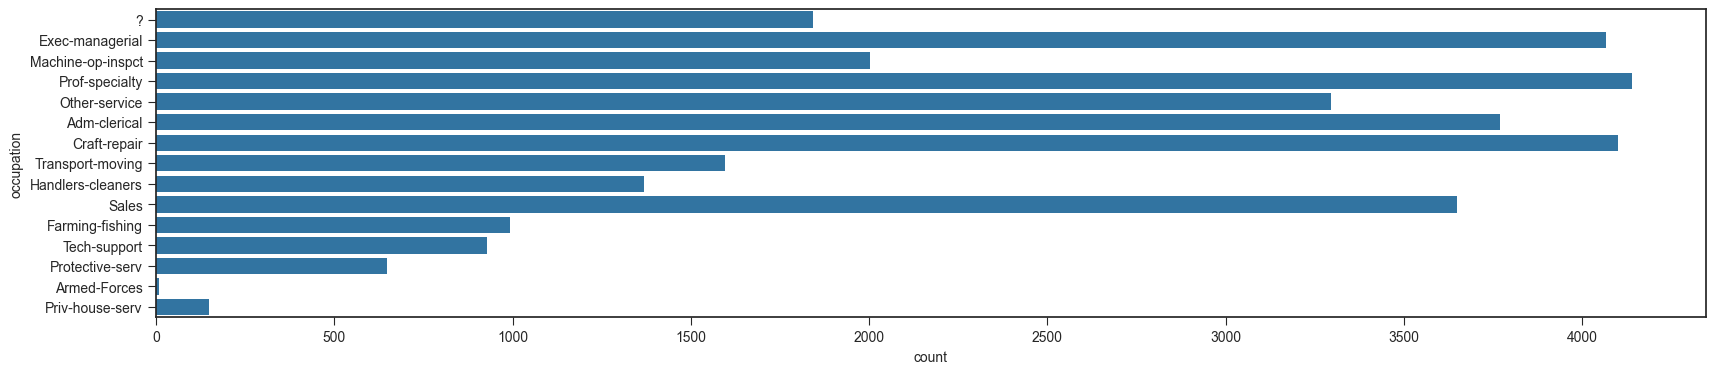

In [20]:
fig = plt.figure(figsize=(20,4))
plt.style.use('seaborn-v0_8-ticks')
sns.countplot(y="occupation", data=my_df)

<Axes: xlabel='count', ylabel='workclass'>

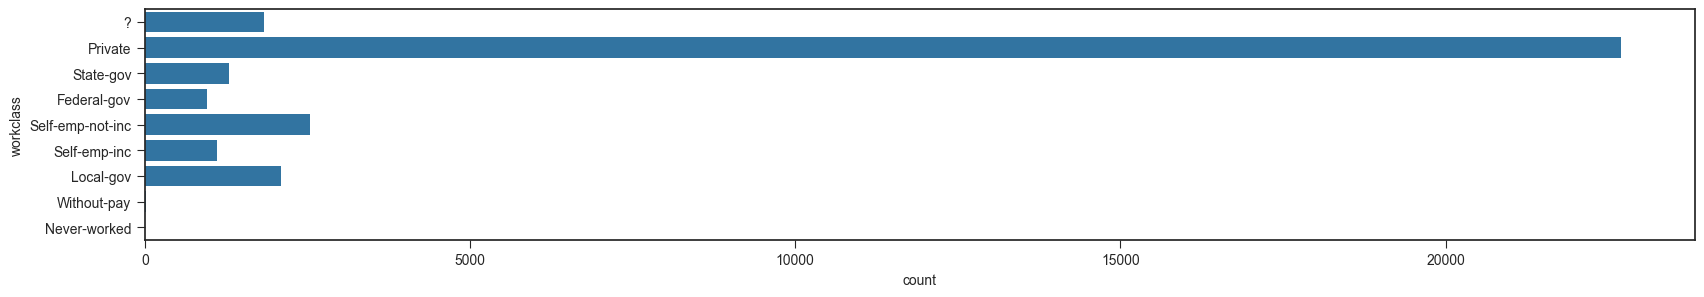

In [21]:
plt.style.use('seaborn-v0_8-ticks')
plt.figure(figsize=(20,3)) 
sns.countplot(y="workclass", data=my_df)

In [22]:
my_df['age_bin'] = pd.cut(my_df['age'], 20)

<Axes: xlabel='age', ylabel='Density'>

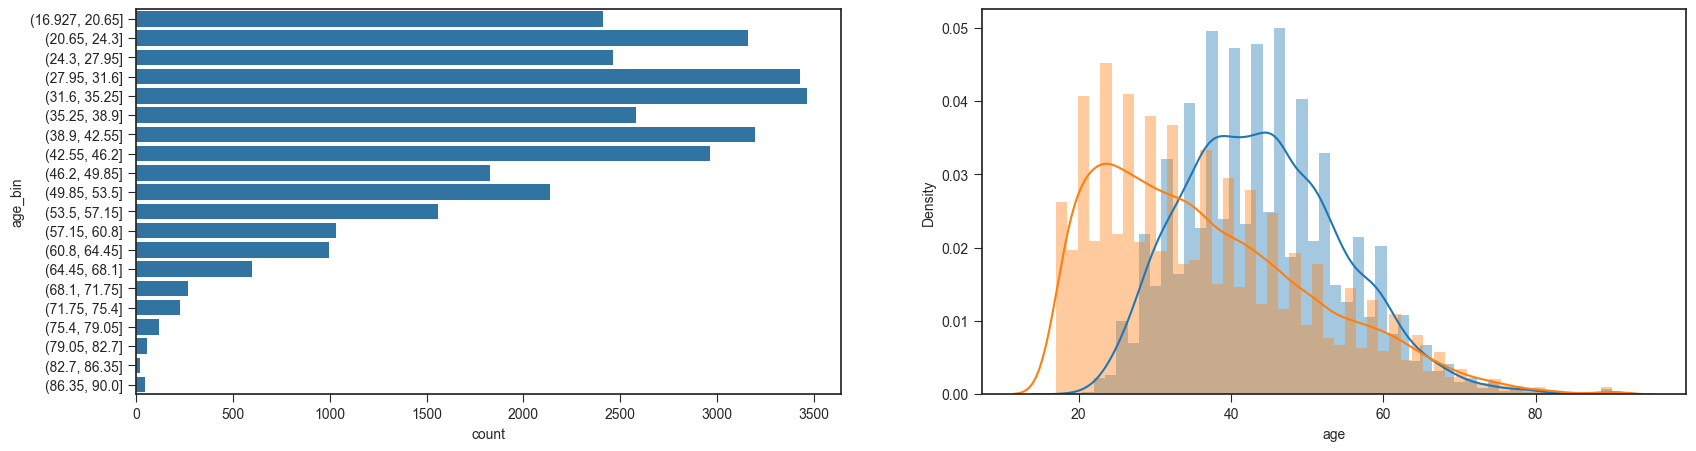

In [23]:
plt.style.use('seaborn-v0_8-ticks')
fig = plt.figure(figsize=(20,5)) 
plt.subplot(1, 2, 1)
sns.countplot(y="age_bin", data=my_df)
plt.subplot(1, 2, 2)
sns.distplot(my_df[my_df['predclass'] == '>50K']['age'], kde_kws={"label": ">$50K"})
sns.distplot(my_df[my_df['predclass'] == '<=50K']['age'], kde_kws={"label": "<=$50K"})

In [24]:
my_df[['predclass', 'age']].groupby(['predclass'], as_index=False).mean().sort_values(by='age', ascending=False)

,predclass,age
1,>50K,44.249841
0,<=50K,36.783738


<Axes: xlabel='race', ylabel='prop'>

<Figure size 2000x500 with 0 Axes>

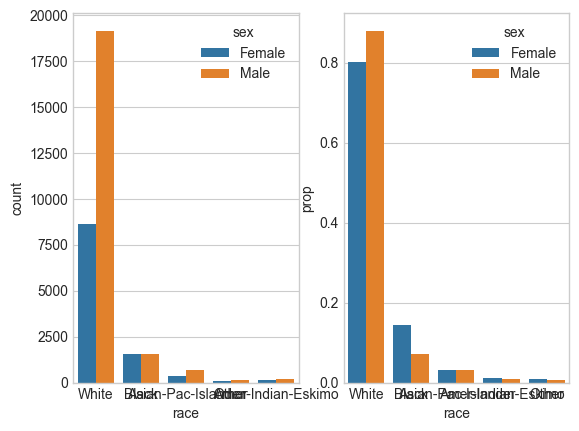

In [25]:
plt.style.use('seaborn-v0_8-whitegrid')
x, y, hue = "race", "prop", "sex"
#hue_order = ["Male", "Female"]
plt.figure(figsize=(20,5)) 
f, axes = plt.subplots(1, 2)
sns.countplot(x=x, hue=hue, data=my_df, ax=axes[0])

prop_df = (my_df[x]
           .groupby(my_df[hue])
           .value_counts(normalize=True)
           .rename(y)
           .reset_index())

sns.barplot(x=x, y=y, hue=hue, data=prop_df, ax=axes[1])

In [26]:
my_df['hours.per.week.bin'] = pd.cut(my_df['hours.per.week'], 10)
my_df['hours.per.week'] = my_df['hours.per.week']

(20.0, 60.0)

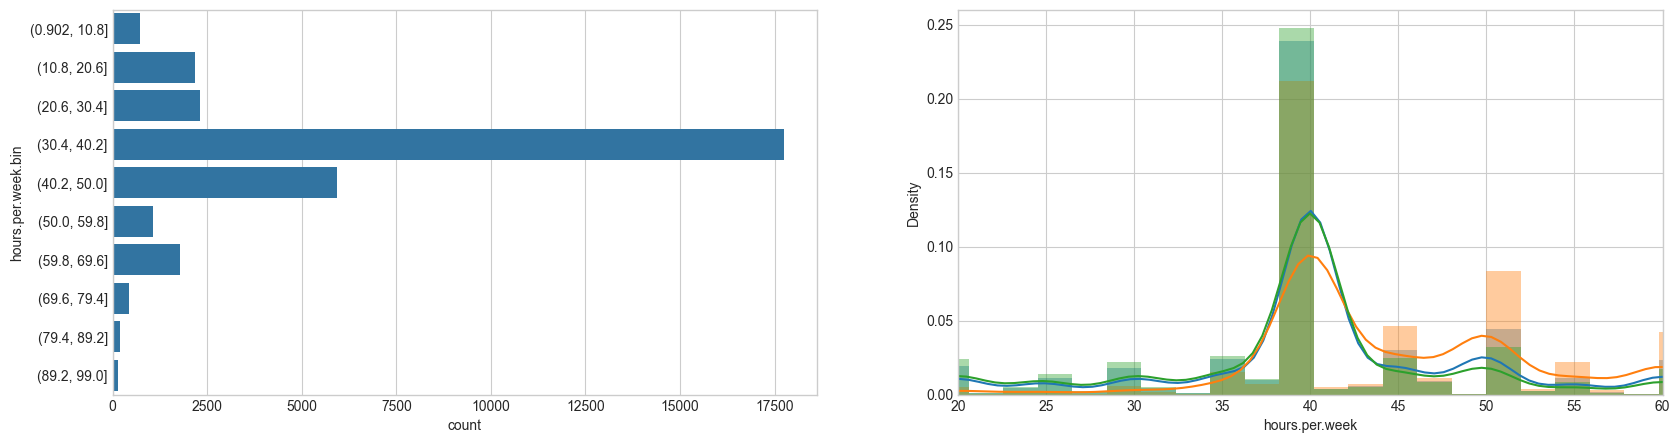

In [27]:
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(20,5)) 
plt.subplot(1, 2, 1)
sns.countplot(y="hours.per.week.bin", data=my_df);
plt.subplot(1, 2, 2)
sns.distplot(my_df['hours.per.week']);
sns.distplot(my_df[my_df['predclass'] == '>50K']['hours.per.week'], kde_kws={"label": ">$50K"})
sns.distplot(my_df[my_df['predclass'] == '<=50K']['hours.per.week'], kde_kws={"label": "<$50K"})
plt.ylim(0, None)
plt.xlim(20, 60)

<Axes: xlabel='age', ylabel='hours.per.week'>

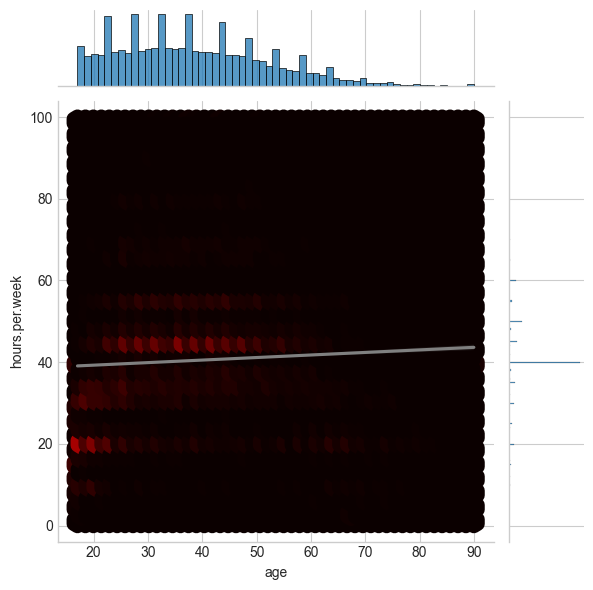

In [28]:
g = sns.jointplot(
    x='age', 
    y='hours.per.week',
    data=my_df, 
    kind='hex', 
    cmap='hot', 
    linewidth=10
)

# 2. Add the regression line using explicit x and y keywords
sns.regplot(
    x=my_df['age'], 
    y=my_df['hours.per.week'], 
    ax=g.ax_joint, 
    scatter=False, 
    color='grey'
)

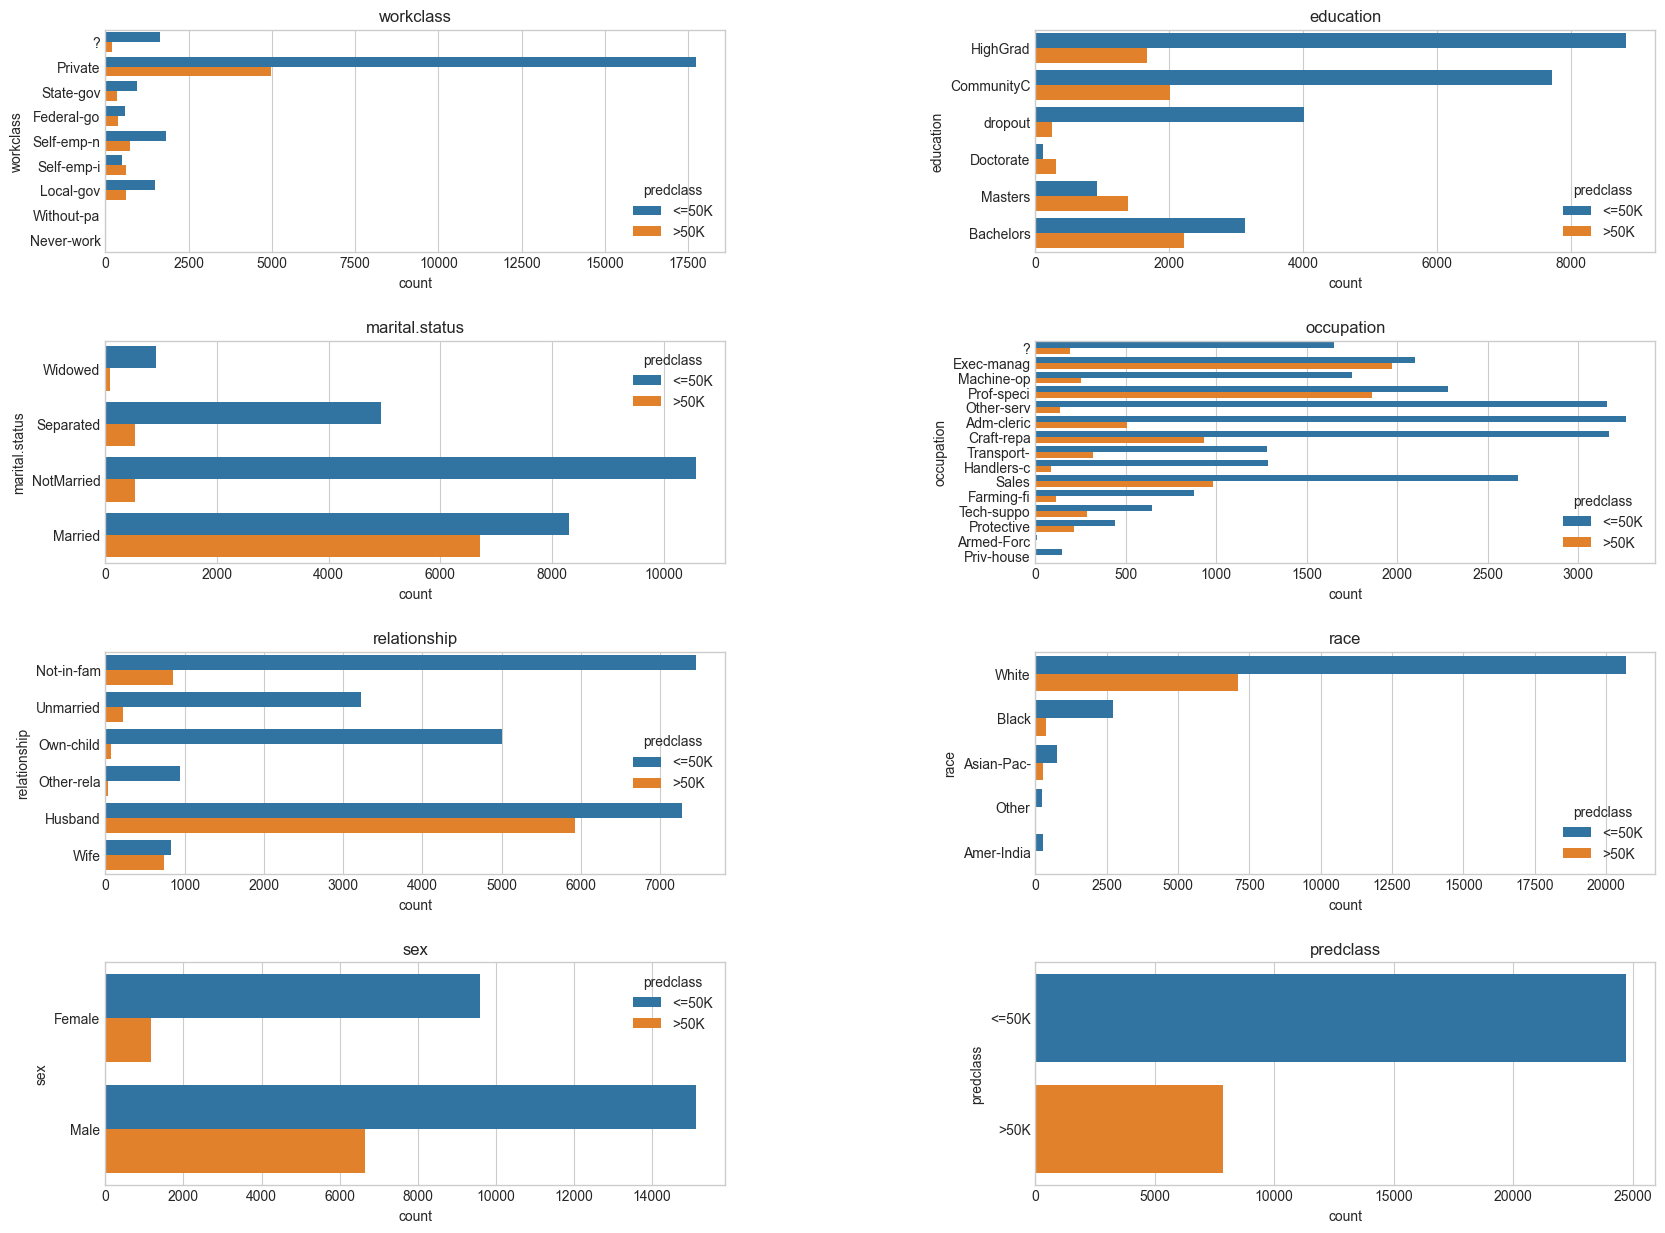

In [29]:
import math

def plot_bivariate_bar(
    dataset, hue, cols=5, width=20, height=15, hspace=0.2, wspace=0.5
):
    # 1. FIX: Changed np.object to standard python 'object' type
    dataset = dataset.select_dtypes(include=["object"])

    plt.style.use("seaborn-v0_8-whitegrid")
    fig = plt.figure(figsize=(width, height))
    fig.subplots_adjust(
        left=None, bottom=None, right=None, top=None, wspace=wspace, hspace=hspace
    )
    rows = math.ceil(float(dataset.shape[1]) / cols)

    for i, column in enumerate(dataset.columns):
        ax = fig.add_subplot(rows, cols, i + 1)
        ax.set_title(column)

        # 2. FIX: Changed np.object check to 'object' string name
        if dataset.dtypes[column] == "object":
            # 3. FIX: explicitly using keyword arguments for Seaborn 0.12+ compatibility
            g = sns.countplot(y=column, hue=hue, data=dataset, ax=ax)

            # 4. FIX: Use modern Matplotlib set_yticklabels syntax to avoid warning errors
            substrings = [s.get_text()[:10] for s in g.get_yticklabels()]
            g.set_yticks(g.get_yticks())  # Fixes a common Matplotlib warning
            g.set_yticklabels(substrings)


bivariate_df = my_df.loc[
    :,
    [
        "workclass",
        "education",
        "marital.status",
        "occupation",
        "relationship",
        "race",
        "sex",
        "predclass",
    ],
]

plot_bivariate_bar(
    bivariate_df,
    hue="predclass",
    cols=2,
    width=20,
    height=15,
    hspace=0.4,
    wspace=0.5,
)

<Axes: xlabel='occupation', ylabel='age'>

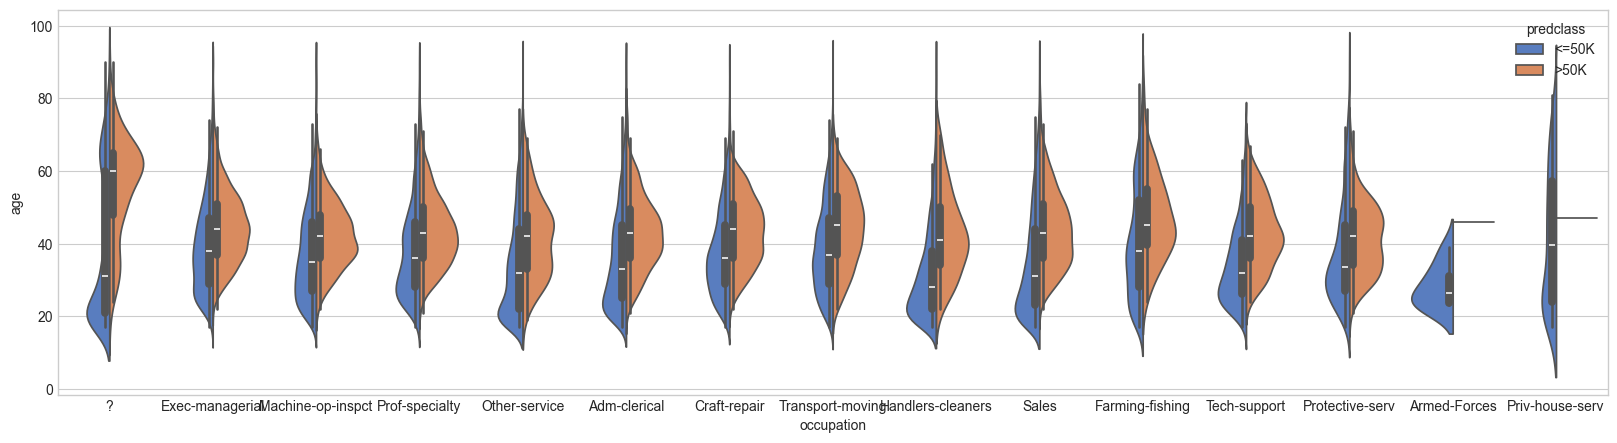

In [30]:
from matplotlib import pyplot
a4_dims = (20, 5)
fig, ax = pyplot.subplots(figsize=a4_dims)
ax = sns.violinplot(x="occupation", y="age", hue="predclass",
                    data=my_df, gridsize=100, palette="muted", split=True, saturation=0.75)
ax

<Axes: xlabel='race', ylabel='age'>

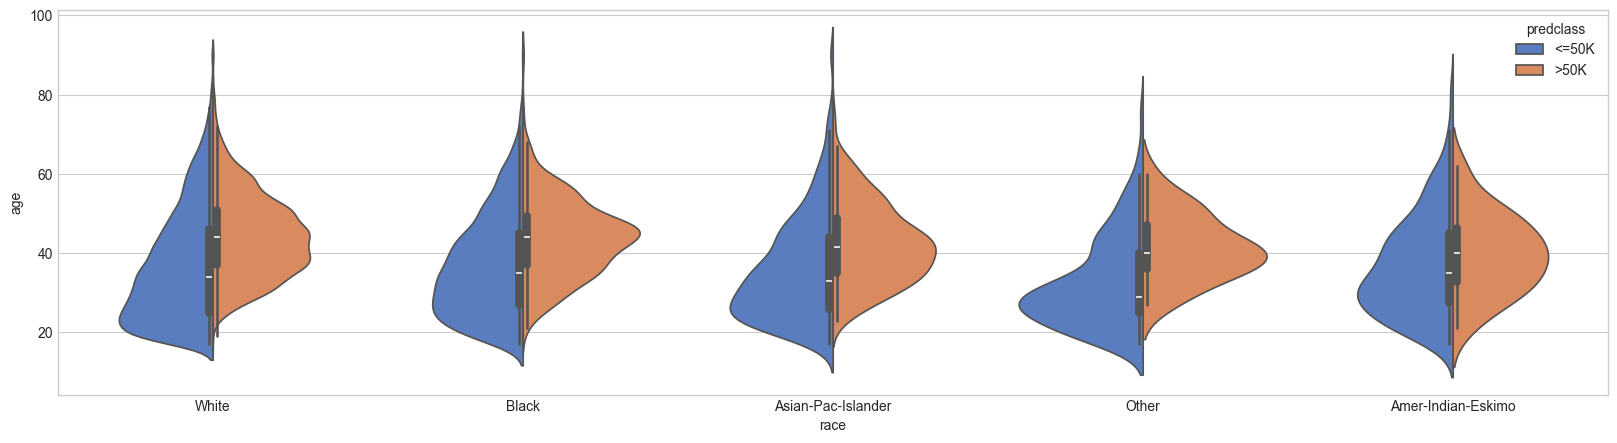

In [31]:
from matplotlib import pyplot
a4_dims = (20, 5)
fig, ax = pyplot.subplots(figsize=a4_dims)
ax = sns.violinplot(x="race", y="age", hue="predclass",
                    data=my_df, gridsize=100, palette="muted", split=True, saturation=0.75)
ax

In [32]:
my_df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,predclass,age_bin,hours.per.week.bin
0,90,?,77053,HighGrad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K,"(86.35, 90.0]","(30.4, 40.2]"
1,82,Private,132870,HighGrad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K,"(79.05, 82.7]","(10.8, 20.6]"
2,66,?,186061,CommunityCollege,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K,"(64.45, 68.1]","(30.4, 40.2]"
3,54,Private,140359,dropout,4,Separated,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K,"(53.5, 57.15]","(30.4, 40.2]"
4,41,Private,264663,CommunityCollege,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K,"(38.9, 42.55]","(30.4, 40.2]"


In [33]:
# Prepare deployment-safe model data.

model_df = my_df.copy()

education_map = {
    'Preschool': 'dropout', '1st-4th': 'dropout', '5th-6th': 'dropout',
    '7th-8th': 'dropout', '9th': 'dropout', '10th': 'dropout',
    '11th': 'dropout', '12th': 'dropout',
    'HS-Grad': 'HighGrad', 'HS-grad': 'HighGrad',
    'Some-college': 'CommunityCollege', 'Assoc-acdm': 'CommunityCollege',
    'Assoc-voc': 'CommunityCollege', 'Bachelors': 'Bachelors',
    'Masters': 'Masters', 'Prof-school': 'Masters', 'Doctorate': 'Doctorate'
}
marital_map = {
    'Never-married': 'NotMarried', 'Married-AF-spouse': 'Married',
    'Married-civ-spouse': 'Married', 'Married-spouse-absent': 'NotMarried',
    'Separated': 'Separated', 'Divorced': 'Separated', 'Widowed': 'Widowed'
}

model_df['education'] = model_df['education'].replace(education_map)
model_df['marital.status'] = model_df['marital.status'].replace(marital_map)

drop_elements = ['education', 'native.country', 'age_bin', 'hours.per.week.bin']
y_raw = model_df['predclass'].astype(str).str.strip()
X_raw = model_df.drop(columns=drop_elements + ['predclass'], errors='ignore').copy()

categorical_columns = X_raw.select_dtypes(include=['object']).columns.tolist()
for col in categorical_columns:
    X_raw[col] = X_raw[col].astype('string').str.strip()

print('Raw model features:', list(X_raw.columns))


Raw model features: ['age', 'workclass', 'fnlwgt', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week']


In [34]:
# Split BEFORE fitting encoders/scalers.
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.20, random_state=2, stratify=y_raw
)

target_mapping = {'<=50K': 0, '>50K': 1}
unknown_targets = sorted(set(y_train_raw.unique()) - set(target_mapping))
if unknown_targets:
    raise ValueError(f'Unexpected target labels: {unknown_targets}')

y_train = y_train_raw.map(target_mapping).astype(int)
y_test = y_test_raw.map(target_mapping).astype(int)


In [35]:
# Fit preprocessing components ONLY on X_train.

numeric_columns = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = X_train_raw.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

numeric_medians = {
    col: float(pd.to_numeric(X_train_raw[col], errors='coerce').median())
    for col in numeric_columns
}

category_mappings = {}
for col in categorical_columns:
    values = X_train_raw[col].astype('string').fillna('__MISSING__').str.strip().unique().tolist()
    category_mappings[col] = {value: idx for idx, value in enumerate(sorted(values))}

def transform_features(df):
    df = df.copy()
    missing = [c for c in X_train_raw.columns if c not in df.columns]
    if missing:
        raise ValueError(f'Missing required columns: {missing}')
    df = df[X_train_raw.columns].copy()

    for col in numeric_columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(numeric_medians[col])

    for col in categorical_columns:
        series = df[col].astype('string').fillna('__MISSING__').str.strip()
        df[col] = series.map(category_mappings[col]).fillna(-1).astype(float)

    return df.astype(float)

X_train_encoded = transform_features(X_train_raw)
X_test_encoded = transform_features(X_test_raw)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)
feature_names = X_train_encoded.columns.tolist()

print('Final features:', feature_names)


Final features: ['age', 'workclass', 'fnlwgt', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week']


In [36]:
# ============================================================
# TRAIN MODELS AND EXPORT PKL FILES FOR STREAMLIT DEPLOYMENT
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    matthews_corrcoef
)

# ============================================================
# OUTPUT DIRECTORY
# ============================================================

MODEL_DIR = "trained_models"

os.makedirs(MODEL_DIR, exist_ok=True)

# ============================================================
# DEFINE MODELS
# ============================================================

models = {
    "Random Forest": RandomForestClassifier(
        random_state=42,
        max_depth=10,
        min_samples_leaf=4,
        n_estimators=40
    ),

    "Gaussian NB": GaussianNB(),

    "K-Nearest Neighbors": KNeighborsClassifier(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=8,
        min_samples_leaf=4
    ),

    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    )
}

# ============================================================
# CREATE TARGET MAPPINGS
# ============================================================

inverse_target_mapping = {
    str(v): k
    for k, v in target_mapping.items()
}

# ============================================================
# SAVE PREPROCESSING ARTIFACTS
#
# Streamlit needs these to preprocess user input exactly
# the same way as the training data.
# ============================================================

preprocessing_artifacts = {
    "feature_names": feature_names,
    "numeric_columns": numeric_columns,
    "categorical_columns": categorical_columns,
    "numeric_medians": numeric_medians,
    "category_mappings": category_mappings,
    "target_mapping": target_mapping,
    "inverse_target_mapping": inverse_target_mapping,
    "scaler": scaler
}

preprocessing_path = os.path.join(
    MODEL_DIR,
    "preprocessing.pkl"
)

joblib.dump(
    preprocessing_artifacts,
    preprocessing_path
)

print(
    f"Preprocessing saved: {preprocessing_path}"
)

# ============================================================
# TRAIN, EVALUATE AND SAVE EACH MODEL
# ============================================================

results_list = []

for name, model in models.items():

    # ========================================================
    # SAFE FILE NAME
    # ========================================================

    safe_name = (
        name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    print("\n" + "=" * 60)
    print(f"Training: {name}")
    print("=" * 60)

    # ========================================================
    # TRAIN MODEL
    # ========================================================

    model.fit(
        X_train_scaled,
        y_train
    )

    # ========================================================
    # SAVE TRAINED MODEL AS PKL
    # ========================================================

    model_path = os.path.join(
        MODEL_DIR,
        f"{safe_name}_model.pkl"
    )

    joblib.dump(
        model,
        model_path
    )

    print(
        f"Model saved: {model_path}"
    )

    # ========================================================
    # TEST PREDICTIONS
    # ========================================================

    y_pred = model.predict(
        X_test_scaled
    )

    # ========================================================
    # PREDICTION PROBABILITIES
    # ========================================================

    y_probs = model.predict_proba(
        X_test_scaled
    )

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    # ========================================================
    # ROC-AUC
    # ========================================================

    if y_probs.shape[1] == 2:

        auc_score = roc_auc_score(
            y_test,
            y_probs[:, 1]
        )

    else:

        auc_score = roc_auc_score(
            y_test,
            y_probs,
            multi_class="ovr"
        )

    # ========================================================
    # STORE MODEL RESULTS
    # ========================================================

    results_list.append({

        "Model": name,

        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),

        "Precision (Macro)": report[
            "macro avg"
        ]["precision"],

        "Recall (Macro)": report[
            "macro avg"
        ]["recall"],

        "F1-Score (Macro)": report[
            "macro avg"
        ]["f1-score"],

        "ROC AUC": auc_score,

        "MCC": matthews_corrcoef(
            y_test,
            y_pred
        ),

        "Model_File": (
            f"{safe_name}_model.pkl"
        )
    })

    # ========================================================
    # VERIFY SAVED MODEL
    # ========================================================

    loaded_model = joblib.load(
        model_path
    )

    loaded_predictions = loaded_model.predict(
        X_test_scaled
    )

    predictions_match = np.array_equal(
        y_pred,
        loaded_predictions
    )

    print(
        f"Verification: "
        f"Predictions match = {predictions_match}"
    )

# ============================================================
# CREATE PERFORMANCE DATAFRAME
# ============================================================

df_results = pd.DataFrame(
    results_list
)

# ============================================================
# SAVE PERFORMANCE METRICS
# ============================================================

metrics_path = os.path.join(
    MODEL_DIR,
    "model_performance_metrics.csv"
)

df_results.to_csv(
    metrics_path,
    index=False
)

print("\n" + "=" * 60)
print("ALL MODELS TRAINED AND EXPORTED SUCCESSFULLY")
print("=" * 60)

# ============================================================
# DISPLAY EXPORTED FILES
# ============================================================

print("\nGenerated files:")

for filename in sorted(
    os.listdir(MODEL_DIR)
):
    print(
        "  ",
        filename
    )

# ============================================================
# DISPLAY PERFORMANCE RESULTS
# ============================================================

print("\nModel Performance:")

display(df_results)

Preprocessing saved: trained_models\preprocessing.pkl

Training: Random Forest
Model saved: trained_models\random_forest_model.pkl
Verification: Predictions match = True

Training: Gaussian NB
Model saved: trained_models\gaussian_nb_model.pkl
Verification: Predictions match = True

Training: K-Nearest Neighbors
Model saved: trained_models\k_nearest_neighbors_model.pkl
Verification: Predictions match = True

Training: Decision Tree
Model saved: trained_models\decision_tree_model.pkl
Verification: Predictions match = True

Training: Logistic Regression
Model saved: trained_models\logistic_regression_model.pkl
Verification: Predictions match = True

ALL MODELS TRAINED AND EXPORTED SUCCESSFULLY

Generated files:
   decision_tree_model.pkl
   gaussian_nb_model.pkl
   k_nearest_neighbors_model.pkl
   logistic_regression_model.pkl
   model_performance_metrics.csv
   preprocessing.pkl
   random_forest_model.pkl

Model Performance:


,Model,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),ROC AUC,MCC,Model_File
0,Random Forest,0.861201,0.835346,0.761603,0.788240,0.918010,0.592376,random_forest_model.pkl
1,Gaussian NB,0.807616,0.766185,0.646830,0.670212,0.855432,0.395394,gaussian_nb_model.pkl
2,K-Nearest Neighbors,0.831721,0.772971,0.749376,0.759735,0.855273,0.521813,k_nearest_neighbors_model.pkl
3,Decision Tree,0.857516,0.835108,0.749812,0.778816,0.905852,0.578668,decision_tree_model.pkl
4,Logistic Regression,0.842008,0.799789,0.738293,0.760729,0.889641,0.534557,logistic_regression_model.pkl


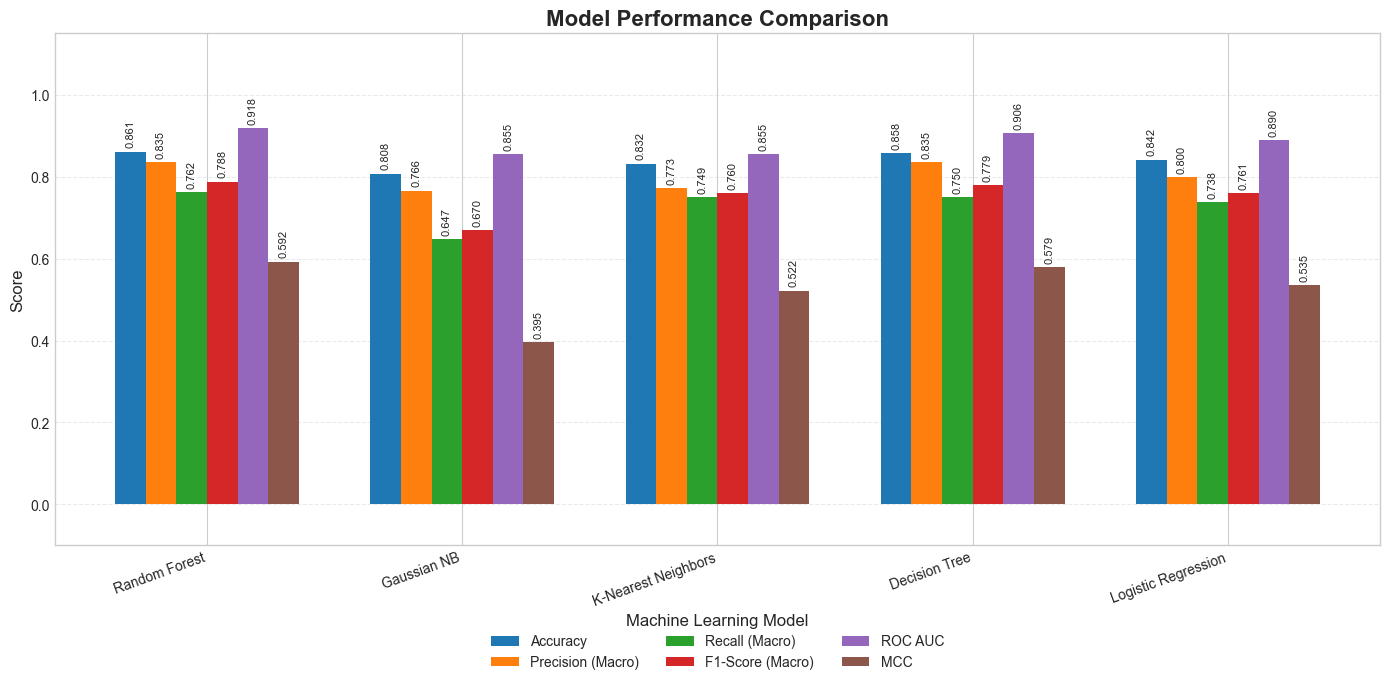

Performance comparison plot saved to: python_models\model_performance_comparison.png


In [37]:
# ============================================================
# PLOT MODEL PERFORMANCE COMPARISON WITH LABELS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Metrics to plot
metrics = [
    "Accuracy",
    "Precision (Macro)",
    "Recall (Macro)",
    "F1-Score (Macro)",
    "ROC AUC",
    "MCC"
]

# Create figure
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(df_results["Model"]))
width = 0.12

# Plot each metric
for i, metric in enumerate(metrics):
    values = df_results[metric].values
    
    bars = ax.bar(
        x + (i - (len(metrics) - 1) / 2) * width,
        values,
        width,
        label=metric
    )
    
    # Add value labels on each bar
    ax.bar_label(
        bars,
        labels=[f"{v:.3f}" for v in values],
        padding=3,
        fontsize=8,
        rotation=90
    )

# Axis labels and title
ax.set_xlabel("Machine Learning Model", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(
    "Model Performance Comparison",
    fontsize=16,
    fontweight="bold"
)

# X-axis labels
ax.set_xticks(x)
ax.set_xticklabels(
    df_results["Model"],
    rotation=20,
    ha="right"
)

# Keep scores within a readable range
ax.set_ylim(-0.1, 1.15)

# Grid and legend
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3
)

plt.tight_layout()

# Save plot
plot_path = os.path.join(
    OUTPUT_DIR,
    "model_performance_comparison.png"
)

plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Performance comparison plot saved to: {plot_path}")